In [11]:
import pytensor
pytensor.config.cxx = "/usr/bin/clang++"

import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pymc as pm
import arviz as az

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set(rc={"figure.figsize" : (25, 15)})
sns.set(font_scale=2)
sns.set_style("ticks")

In [7]:
past_vote_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="Past Vote", dtype={"FIPS" : str})
del past_vote_df["Weighted % D"]
past_vote_df

,FIPS,County,Total Votes Gov 2021 2P,Murphy Votes,% Murphy 2P,RV 2021,% 2P Turnout 2021,Total Votes GE 2024 2P,Harris Votes,% Harris 2P,RV 2024,% 2P Turnout 2024,Margin Murphy Harris,Current RV
0,34001,Atlantic,80713,35736,0.442754,209619,0.385046,127696,61879,0.484581,208224,0.613263,0.041827,202958
1,34003,Bergen,274794,145150,0.528214,688839,0.398923,449756,232660,0.517303,694145,0.647928,-0.010911,676145
2,34005,Burlington,154649,82877,0.535904,354749,0.435939,226391,132275,0.584277,372786,0.607295,0.048373,366045
3,34007,Camden,148178,92162,0.621968,399582,0.370833,243289,155522,0.639248,396984,0.612843,0.017280,387285
4,34009,Cape May,38443,14183,0.368936,74936,0.513011,53799,21648,0.402387,77117,0.697628,0.033451,76221
5,34011,Cumberland,31772,13978,0.439947,97522,0.325793,55252,26577,0.481014,98099,0.563227,0.041067,95833
6,34013,Essex,178062,132520,0.744235,572383,0.311089,308504,224596,0.728016,595845,0.517759,-0.016219,563906
7,34015,Gloucester,99935,44959,0.449882,230662,0.433253,162034,78708,0.485750,226186,0.716375,0.035867,226914
8,34017,Hudson,118509,88066,0.743117,420157,0.282059,224678,144765,0.644322,426585,0.526690,-0.098794,425268
9,34019,Hunterdon,56279,22820,0.405480,107204,0.524971,79386,36995,0.466014,109602,0.724312,0.060534,106408


In [8]:
coords = {
    "county" : past_vote_df["County"]
}

In [60]:
past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].mean(axis=1)

0     0.499154
1     0.523426
2     0.521617
3     0.491838
4     0.605320
5     0.444510
6     0.414424
7     0.574814
8     0.404374
9     0.624641
10    0.483324
11    0.474761
12    0.586364
13    0.579341
14    0.577155
15    0.452852
16    0.506955
17    0.542157
18    0.568903
19    0.486221
20    0.533337
dtype: float64

In [61]:
with pm.Model(coords=coords) as model:
    turnout_pct = pm.Beta("turnout_pct",
                          mu=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].mean(axis=1),
                          sigma=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].std(ddof=1, axis=1),
                          dims="county")

    turnout = pm.Binomial("turnout",
                          p=turnout_pct,
                          n=past_vote_df["Current RV"],
                          dims="county")

    prior_pct_D = pm.Beta("prior_pct_D",
                          mu=past_vote_df[["% Murphy 2P", "% Harris 2P"]].mean(axis=1),
                          sigma=past_vote_df[["% Murphy 2P", "% Harris 2P"]].std(ddof=1, axis=1),
                          dims="county")

    prior_vote_D = pm.Deterministic("prior_vote_D", turnout * prior_pct_D, dims="county")

In [62]:
with model:
    idata = pm.sample()#extend_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [turnout_pct, prior_pct_D]
>Metropolis: [turnout]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


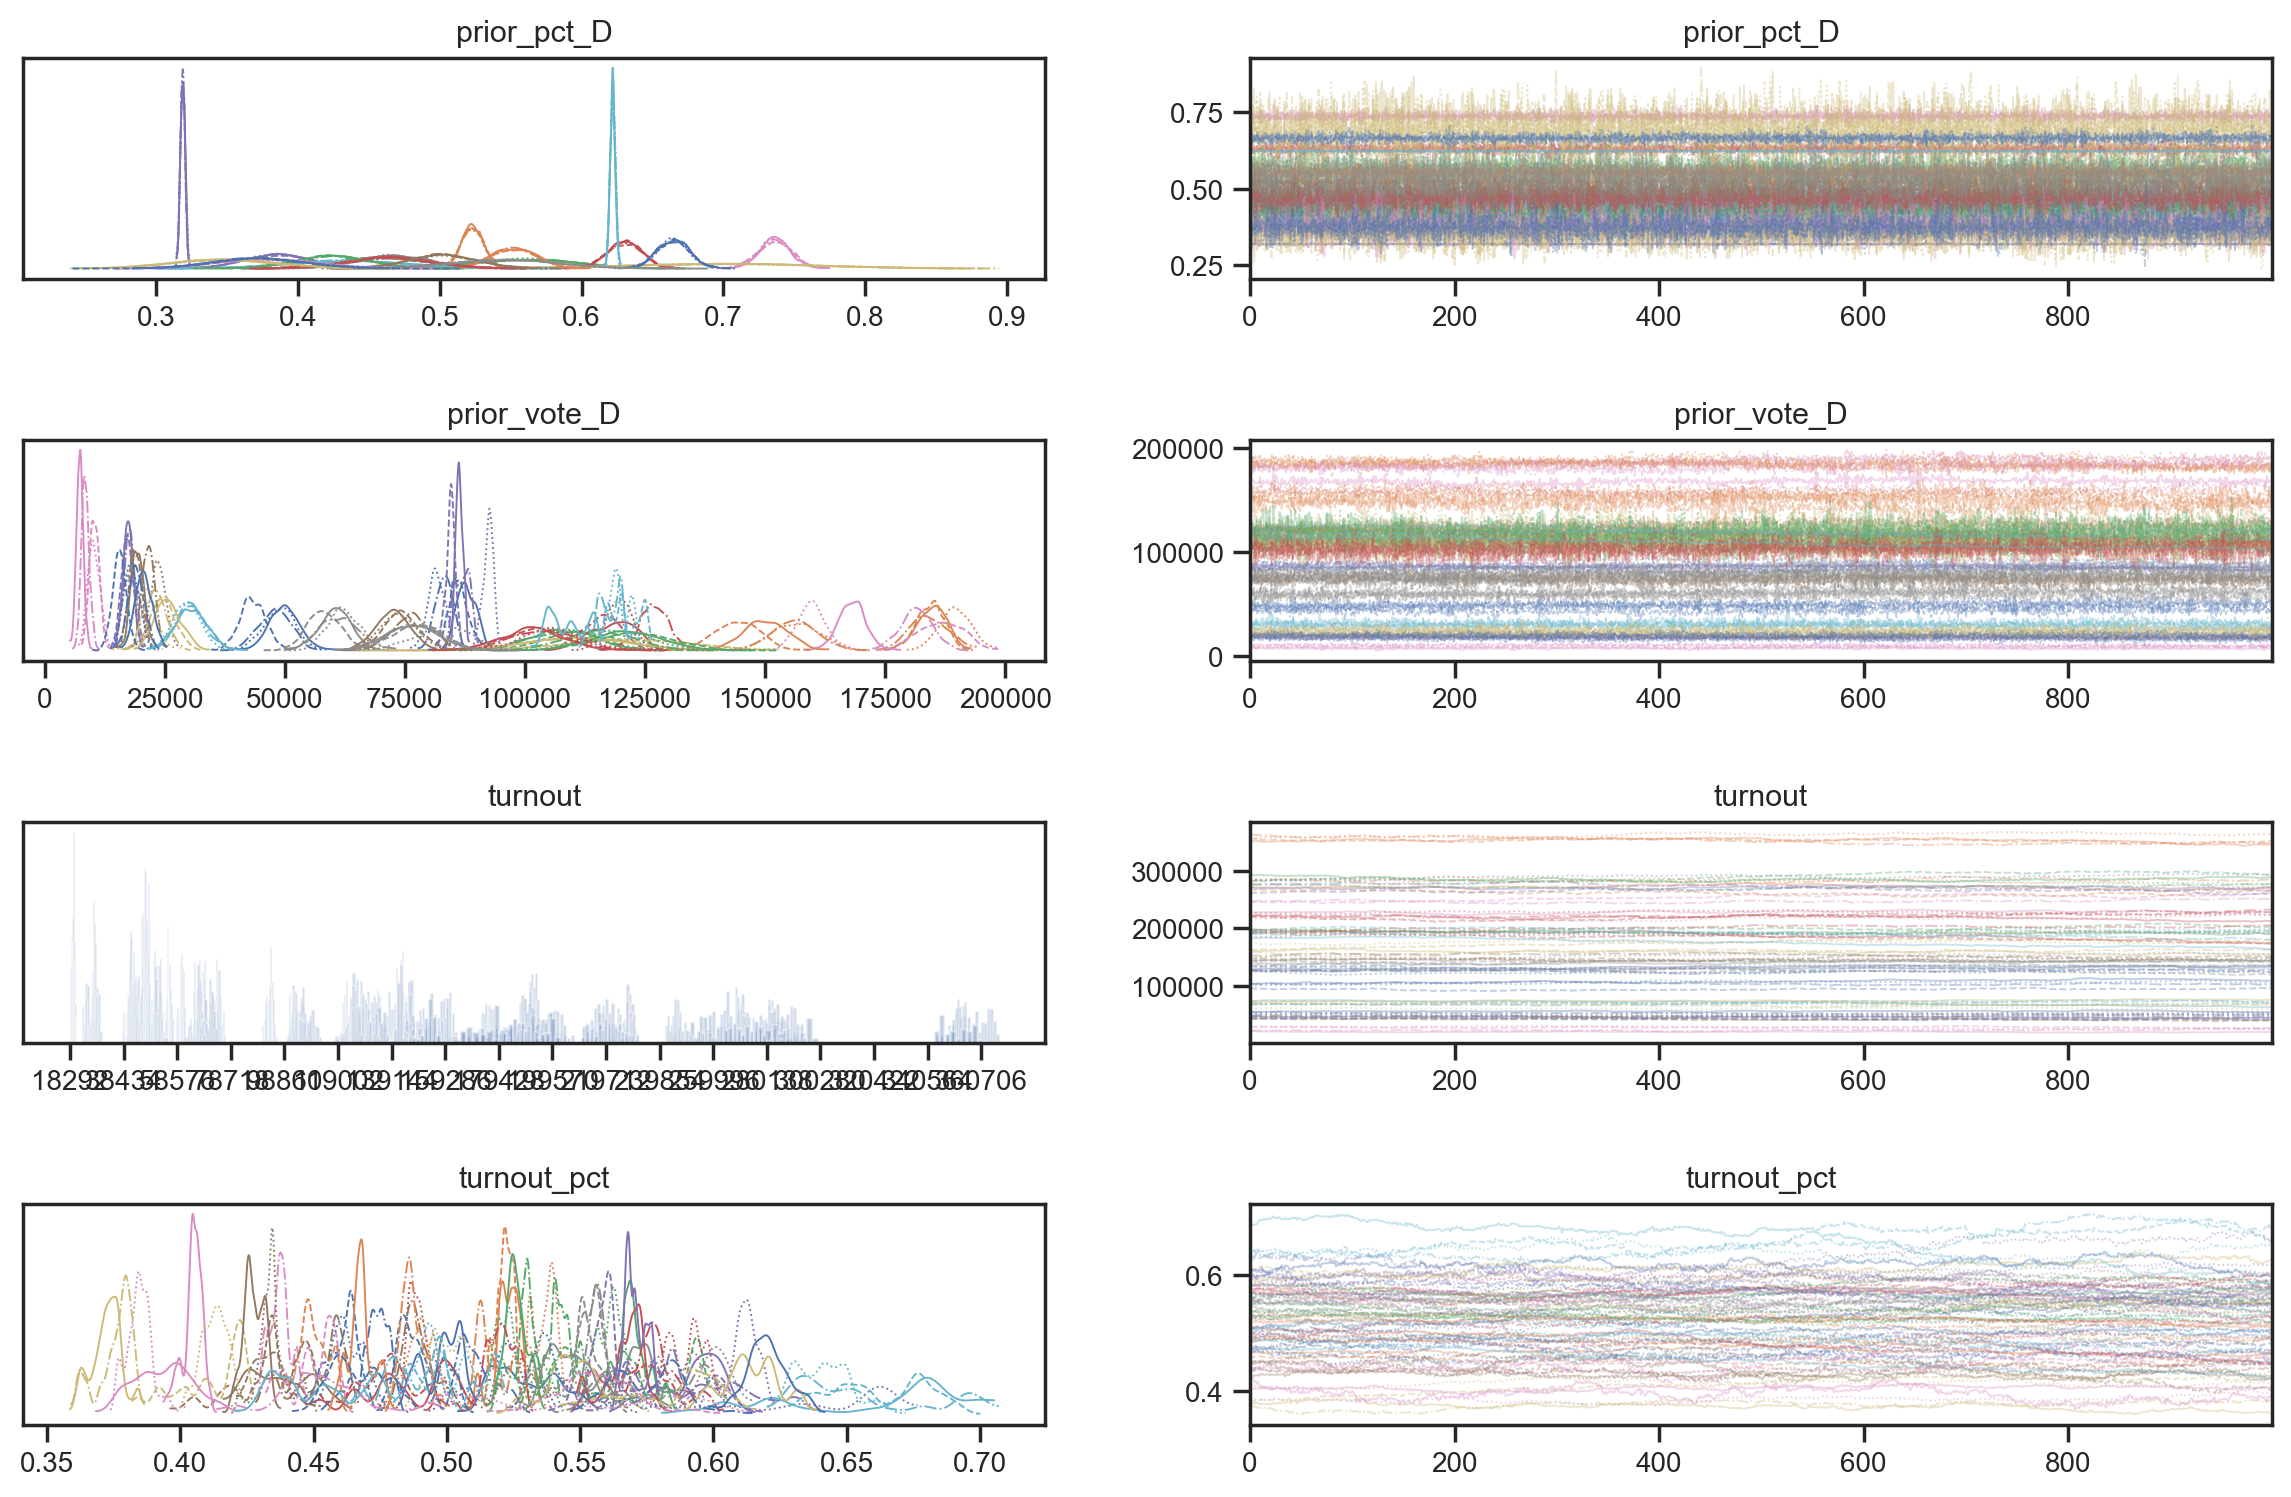

In [63]:
az.plot_trace(idata);
plt.tight_layout()

In [64]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

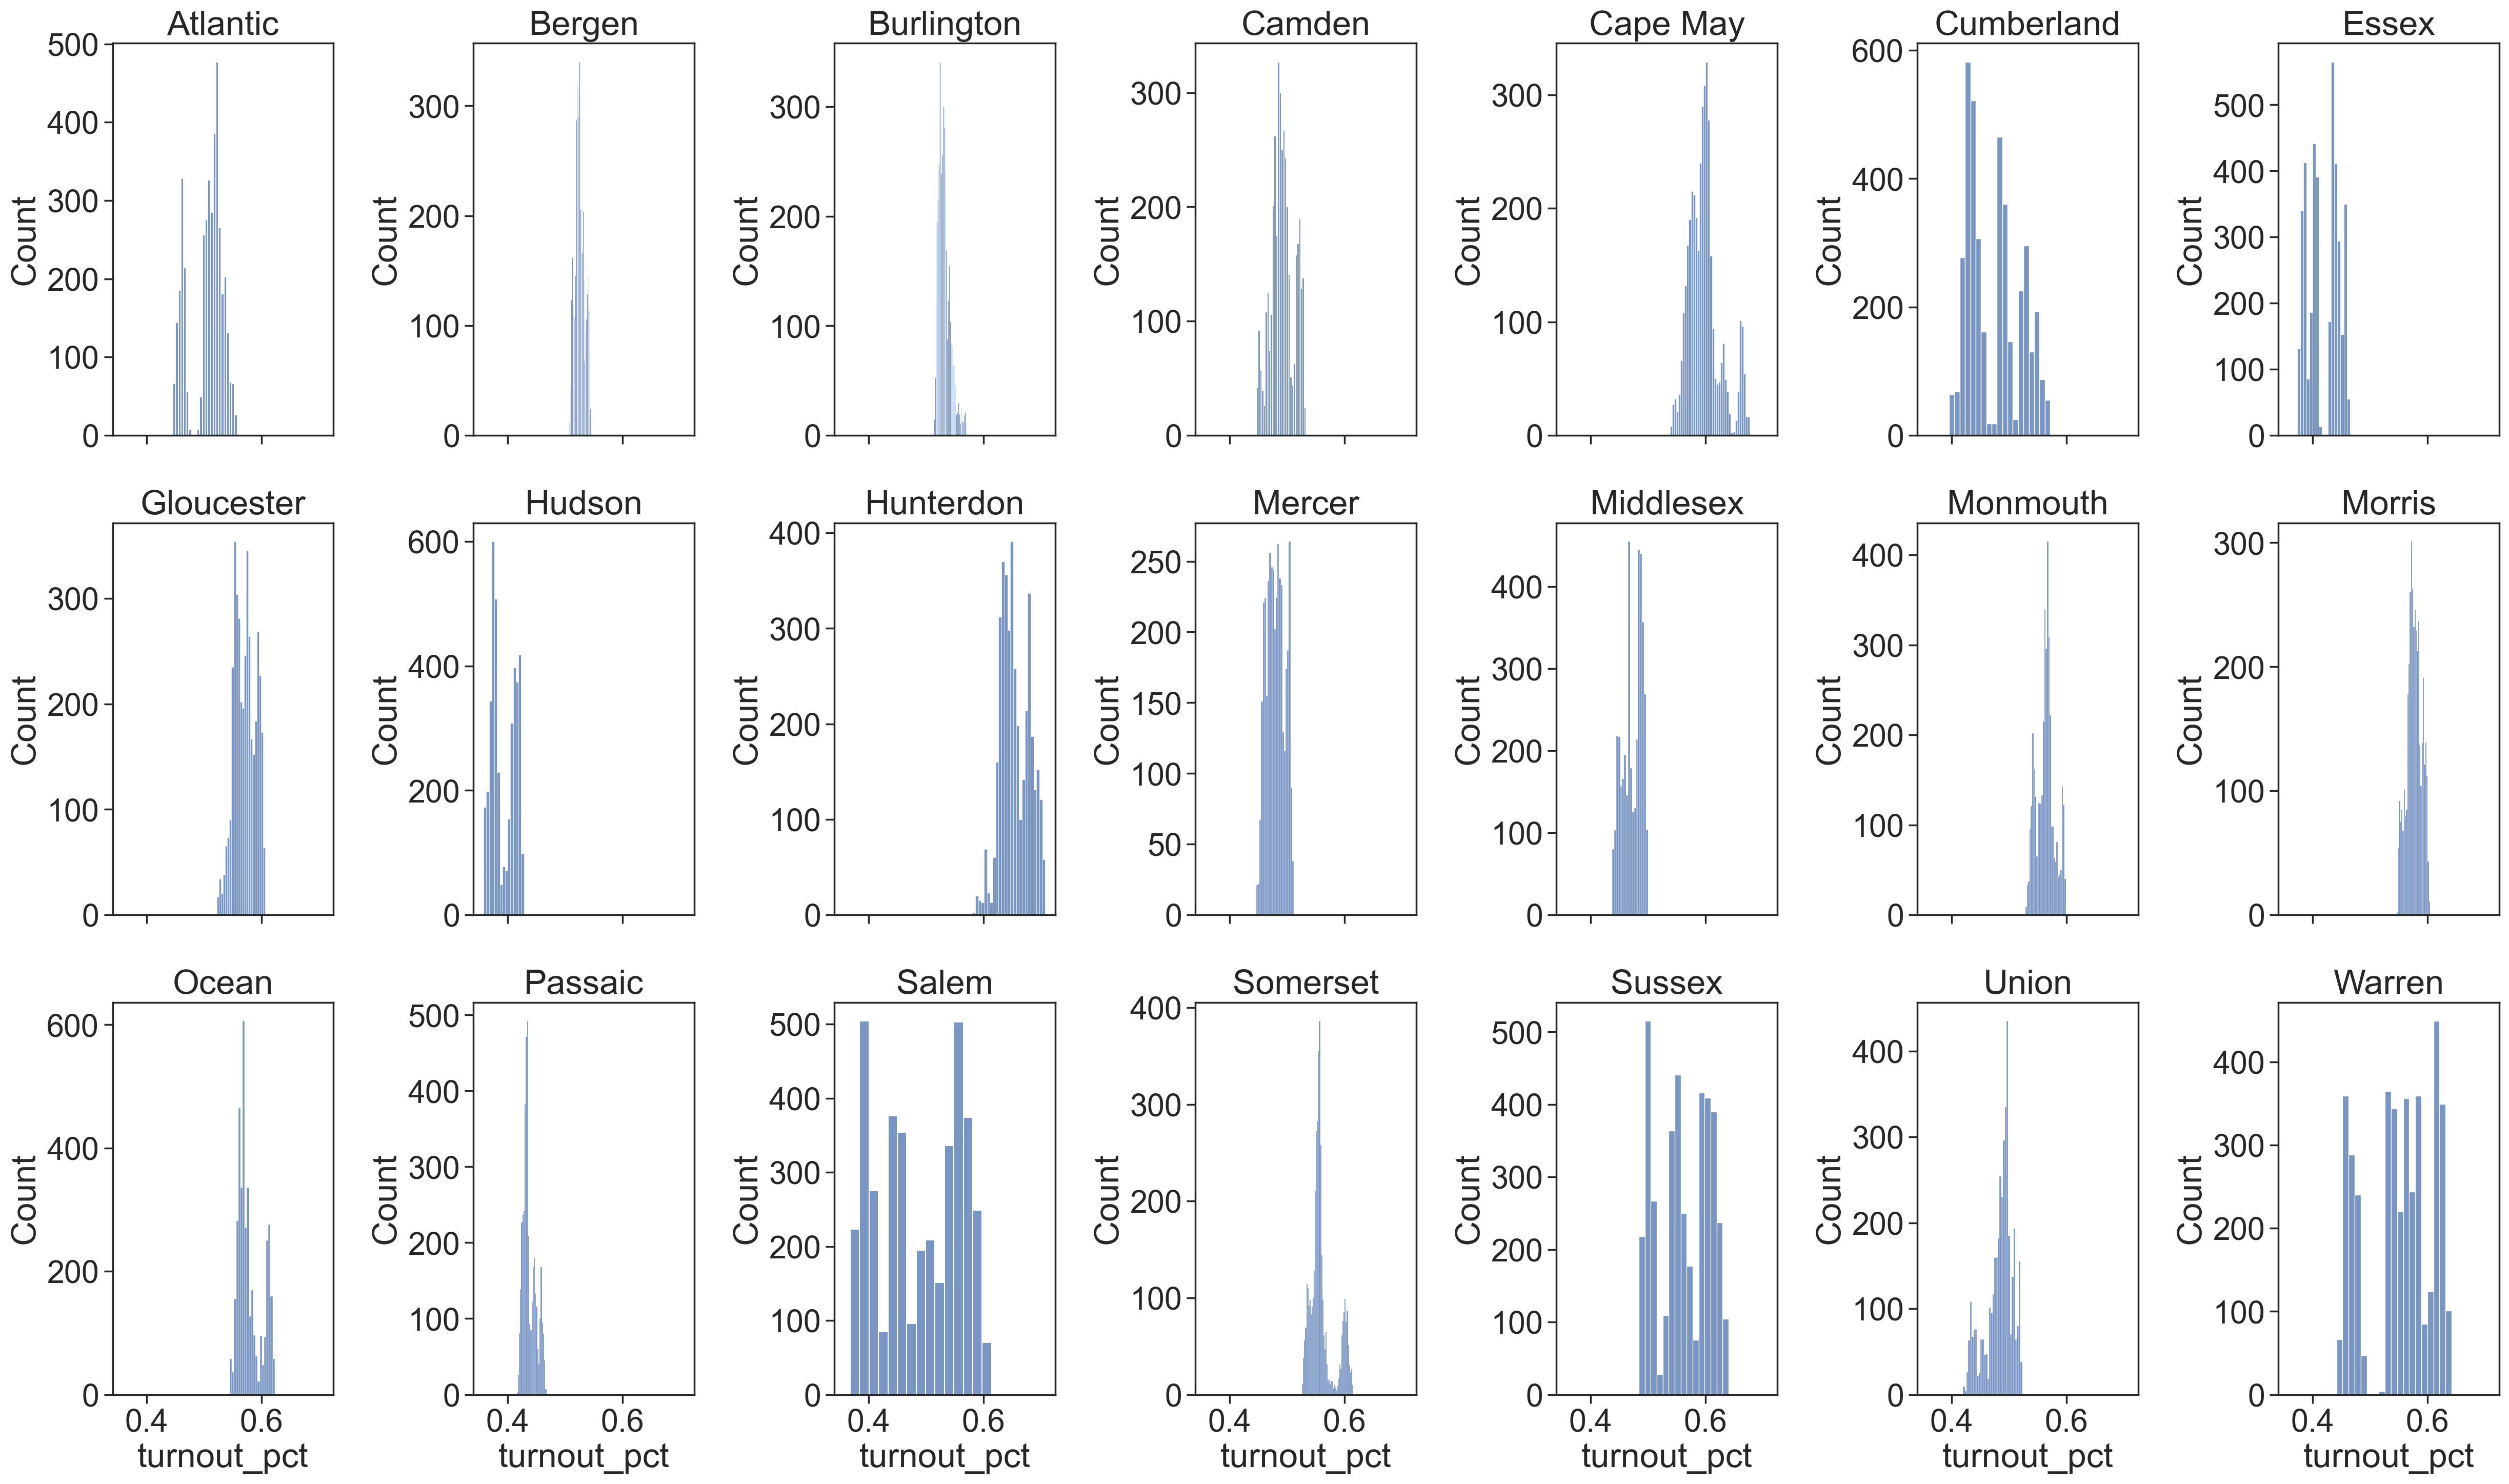

In [65]:
(fig, axs) = plt.subplots(3, 7, sharex=True, sharey=False)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post = idata.posterior.sel(county=c)["turnout_pct"].stack(sample=("chain", "draw"))
    sns.histplot(x=post, ax=ax)
    ax.set_title(str(c.values))

plt.tight_layout()

In [66]:
rows = []
for c in idata.posterior.coords["county"]:
    post = idata.posterior.sel(county=c)["turnout"].stack(sample=("chain", "draw"))
    row = {"County" : str(c.values),
           "Pred" : np.mean(post.values).round(0),
           "Lower" : np.quantile(post.values, 0.025).round(0),
           "Upper" : np.quantile(post.values, 0.975).round(0)}
    rows.append(row)
pandas.DataFrame(rows)

,County,Pred,Lower,Upper
0,Atlantic,102478.0,91758.0,111184.0
1,Bergen,355190.0,345543.0,366153.0
2,Burlington,194543.0,189328.0,205087.0
3,Camden,190503.0,174892.0,204251.0
4,Cape May,45546.0,42269.0,50662.0
5,Cumberland,45355.0,39271.0,53256.0
6,Essex,236313.0,213096.0,258597.0
7,Gloucester,129510.0,121571.0,136538.0
8,Hudson,167075.0,154007.0,180229.0
9,Hunterdon,69612.0,64281.0,74488.0


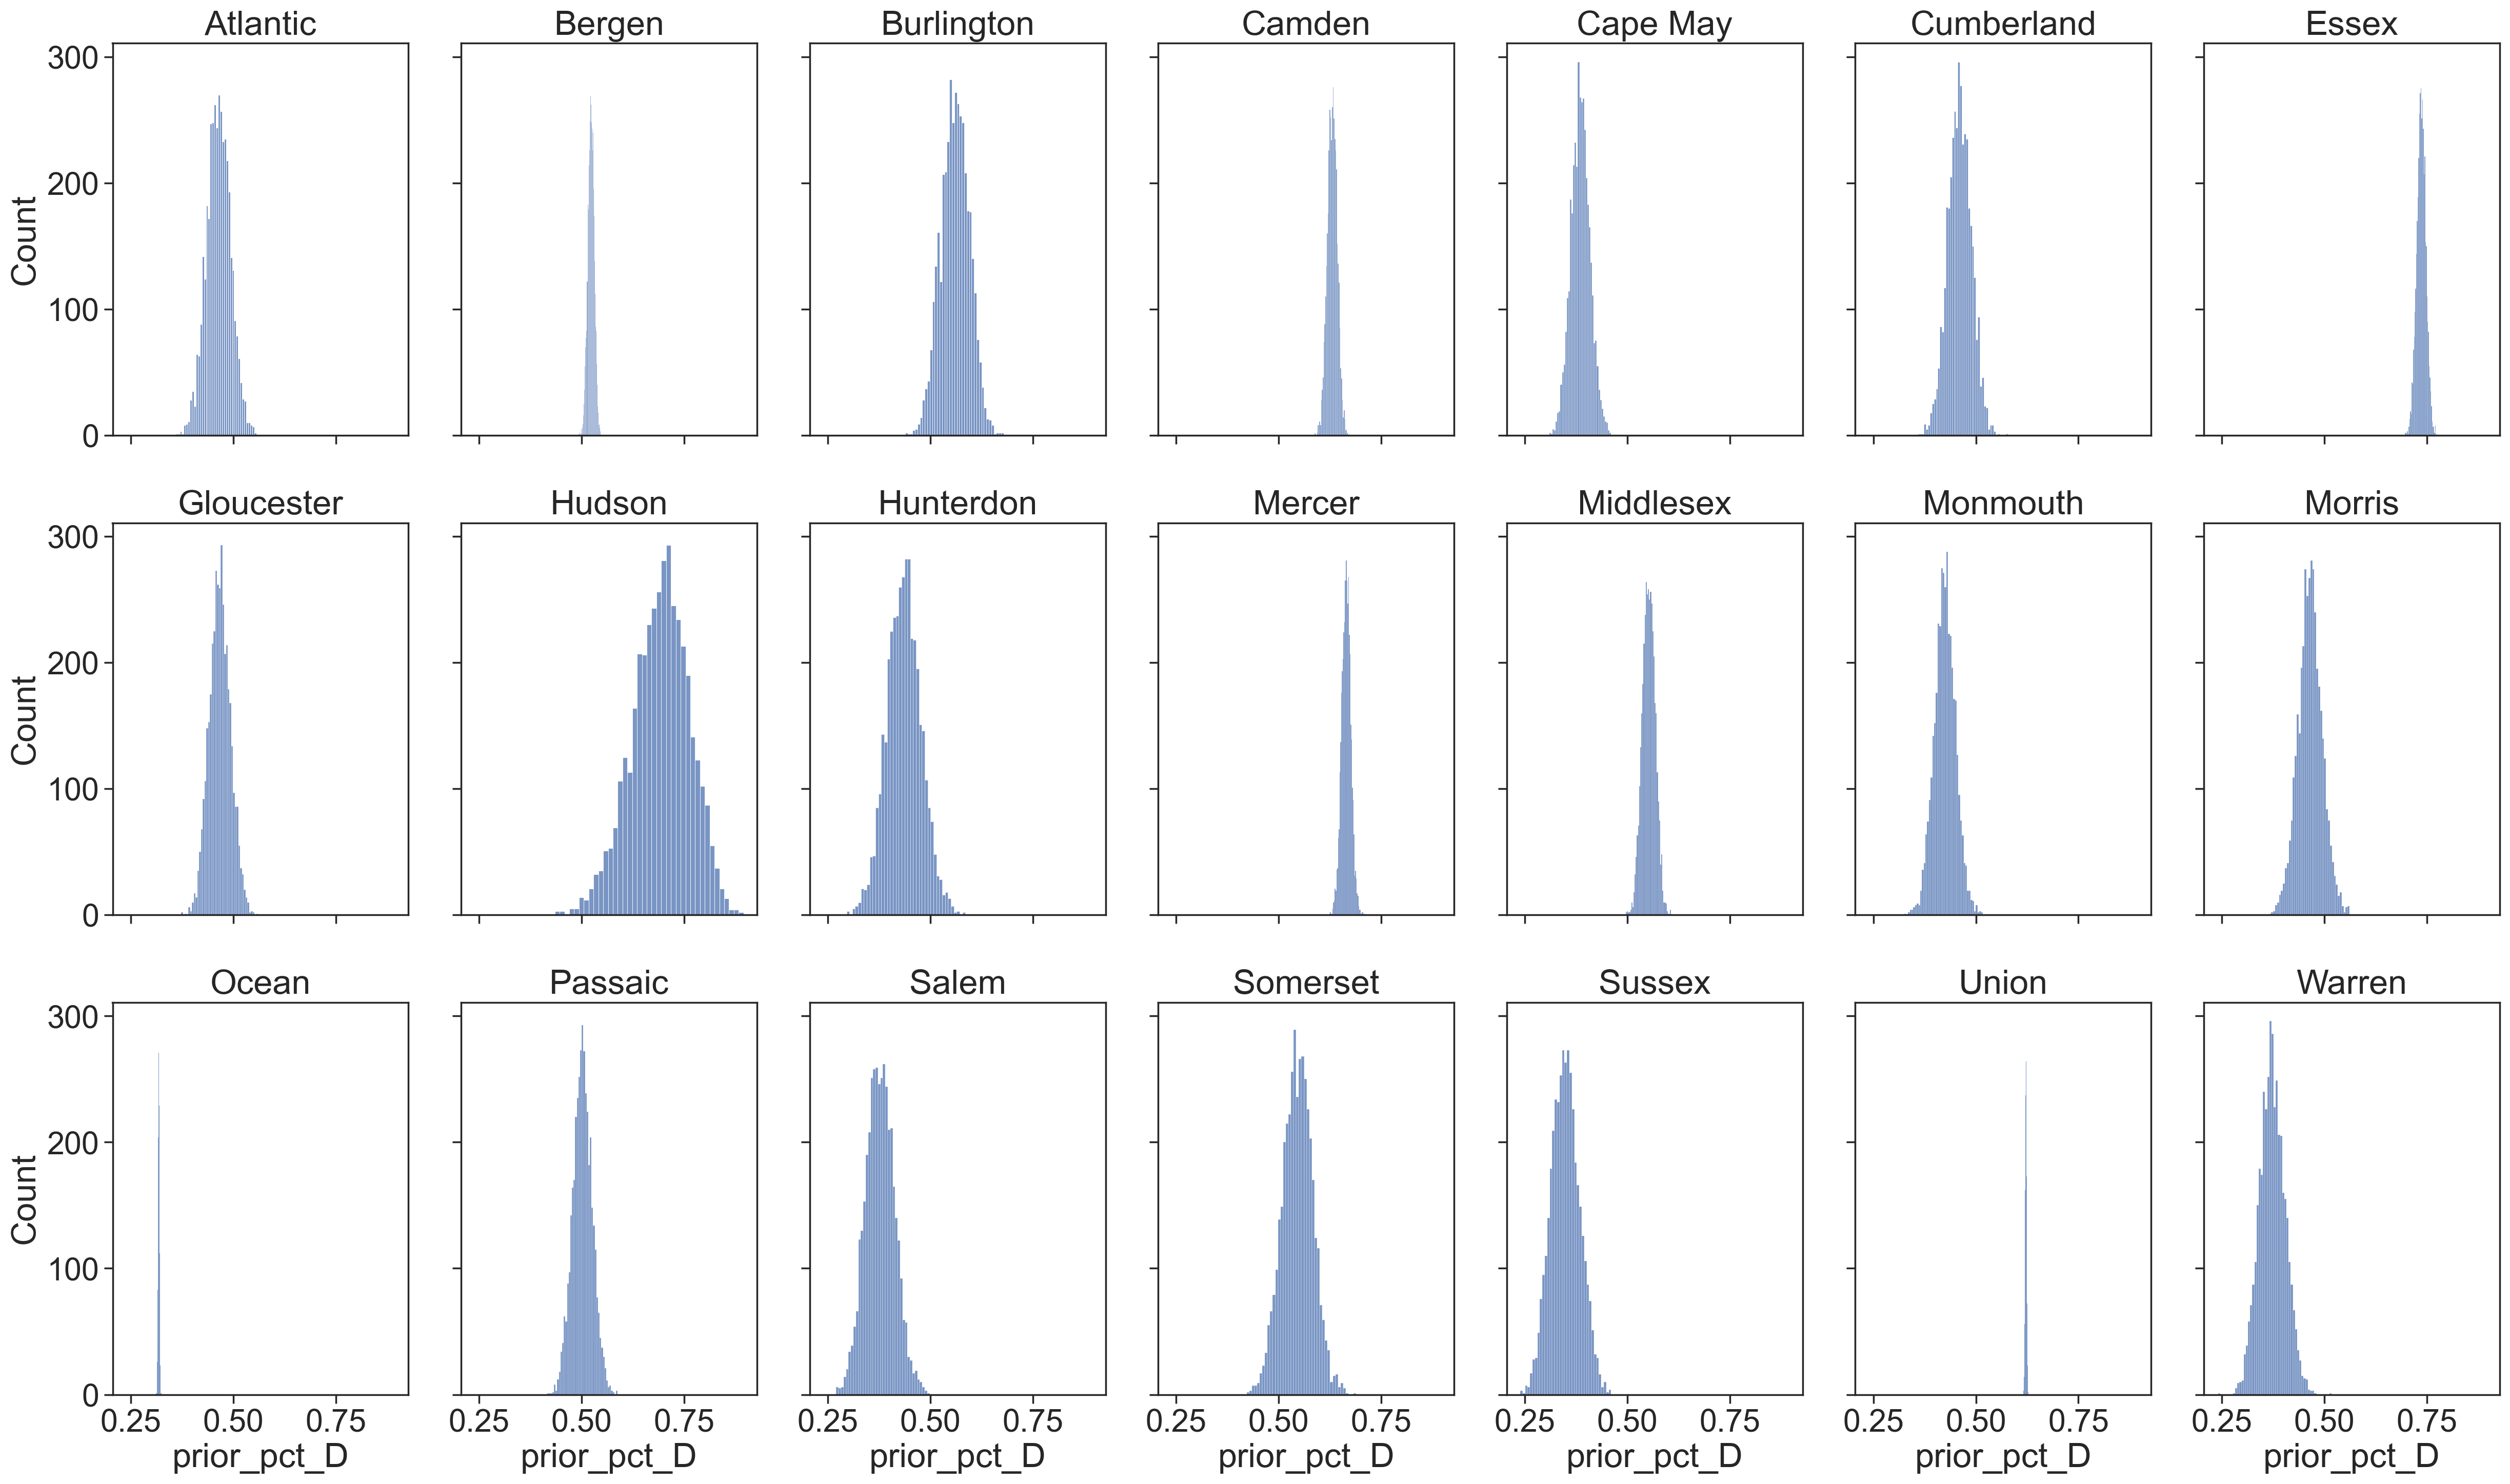

In [67]:
(fig, axs) = plt.subplots(3, 7, sharex=True, sharey=True)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post = idata.posterior.sel(county=c)["prior_pct_D"].stack(sample=("chain", "draw"))
    sns.histplot(x=post, ax=ax)
    ax.set_title(str(c.values))

plt.tight_layout()

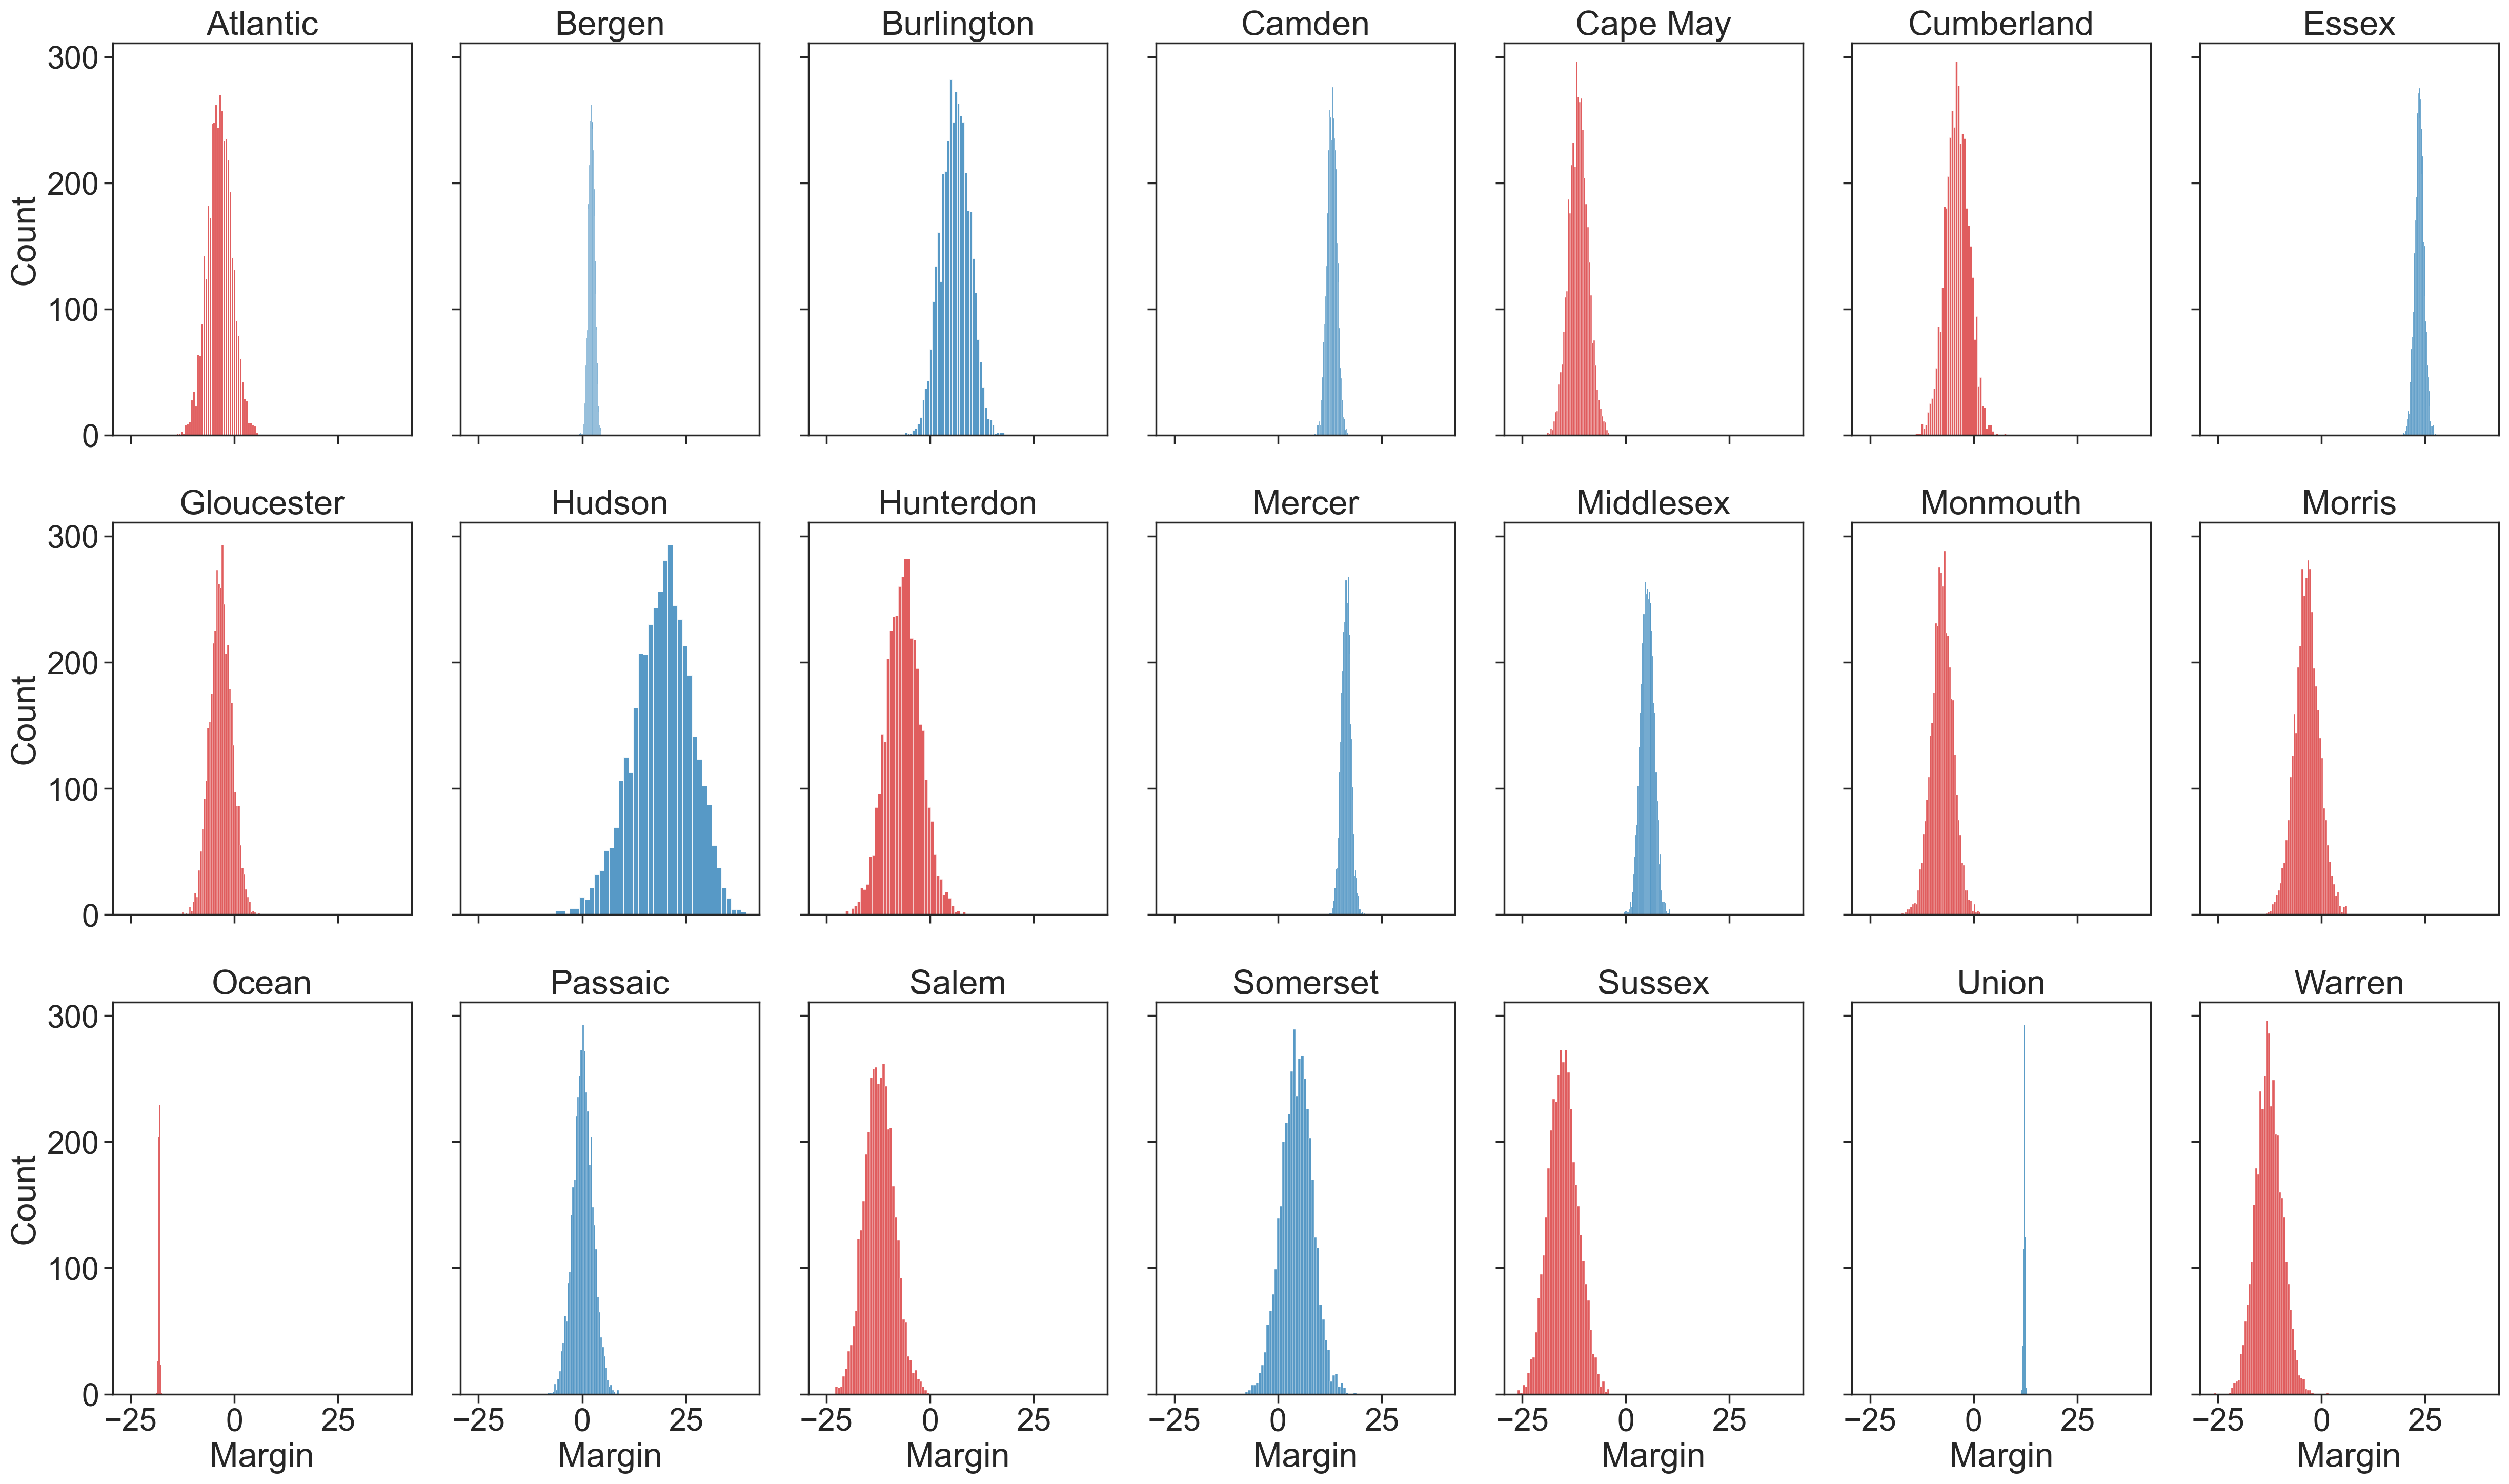

In [86]:
rows = []
(fig, axs) = plt.subplots(3, 7, sharex=True, sharey=True)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    vote = idata.posterior.sel(county=c)["prior_vote_D"].stack(sample=("chain", "draw"))
    turnout = idata.posterior.sel(county=c)["turnout"].stack(sample=("chain", "draw"))
    pct_d = vote / turnout
    margin = (pct_d - 0.5) * 100
    row = {"County" : str(c.values),
           "Pred" : np.mean(margin.values),
           "Lower" : np.quantile(margin.values, 0.025),
           "Upper" : np.quantile(margin.values, 0.975)}
    rows.append(row)
    mean_margin = np.mean(margin.values).mean()
    sns.histplot(x=margin, ax=ax, color=("tab:red" if mean_margin < 0 else "tab:blue"))
    ax.set_title(str(c.values))
    top = max([r.get_height() for r in ax.patches])
    # if mean_margin > 0:
    #     ax.set_xlabel(mean_margin, top + 10, f"Sherill +{np.round(mean_margin, 2)}", color="black", ha="center")
    # else:
    #     ax.text(mean_margin, top + 10, f"Ciattarelli +{np.round(mean_margin, 2) * -1}", color="black", ha="center")
    ax.set_xlabel("Margin")

plt.tight_layout()

In [85]:
pandas.DataFrame(rows).round(1)

,County,Pred,Lower,Upper
0,Atlantic,-3.6,-9.5,2.0
1,Bergen,2.3,0.8,3.8
2,Burlington,6.0,-0.7,12.5
3,Camden,13.1,10.7,15.4
4,Cape May,-11.4,-15.9,-6.8
5,Cumberland,-4.0,-9.7,1.5
6,Essex,23.6,21.4,25.8
7,Gloucester,-3.2,-8.2,2.0
8,Hudson,19.2,4.1,31.7
9,Hunterdon,-6.5,-14.5,1.8
